In [ ]:


1.What is Normalization & Standardization and how is it helpful?

Normalization and standardization are two common techniques in data preprocessing, used to transform data into a format suitable for machine 
learning models.

1.Normalization –
Normalization scales data to fit within a specific range, typically [0, 1] or [-1, 1].
Formula:
The normalized value is calculated as: 
x normalized = (x−min(x))/(max(x)−min(x))
Purpose- 
1. Ensures all features have the same scale, preventing features with large ranges from dominating the model. Keeps all feature values on a consistent 
scale, preventing features with larger ranges from dominating the learning process.
2. Useful for algorithms that rely on distance metrics, such as k-Nearest Neighbors (k-NN) or gradient descent-based methods.

Eg: If feature values are in the range of [10, 1000], normalization will scale them to [0, 1]. For instance, 510 would normalize to:
x normalized = (510−10)/(1000−10) = 0.5
Imagine your feature values are between 10 and 1000. After normalization, they scale to between 0 and 1, preserving relative differences but putting 
everything on the same range.

2. Standardization -
Standardization scales data to have a mean of 0 and a standard deviation of 1. It transforms the data based on the z-score.
Formula:
The standardized value is calculated as:
z=(x−μ)/σ
Where:
•	x: Original value.
•	μ\mu: Mean of the data.
•	σ\sigma: Standard deviation of the data.

Purpose:
•	Centers the data around 0 and ensures all features contribute equally, regardless of their original scale.
•	Especially important for algorithms like Principal Component Analysis (PCA) or regularized methods (e.g., SVM, Logistic Regression).
Example:
•	If the mean of a feature is 50 and its standard deviation is 10, a value of 70 would standardize to:
z=70−50/10=2


When to Use?
•	Normalization: Use when you know the data is bounded and you need all features in a fixed range, especially for distance-based or scaling-sensitive 
algorithms.
•	Standardization: Use when data is not bounded (e.g., Gaussian distribution) or for algorithms assuming data is distributed around a mean (e.g., 
linear regression). Standardization transforms data to have a mean of 0 and a standard deviation of 1, helping align data with a normal (Gaussian) 
distribution.

How Is It Helpful?
1.	Improves Model Performance: Both techniques ensure faster convergence during training by aligning features to similar scales.
2.	Prevents Bias: Eliminates dominance of features with larger ranges.
3.	Enhances Accuracy: Reduces noise and improves generalization on unseen data.
4.	Facilitates Comparison: Makes features easier to compare during exploratory analysis.
These techniques ensure your model learns effectively and interprets all features fairly. 


What is the range of values before and after standardization and normalization?

### Range of Values Before and After Normalization and Standardization

1. Before Preprocessing:
   - The range of values depends entirely on the dataset. For example:
     - Numeric features may have ranges like [0, 1000], [-500, 300], or [20, 80].
     - The spread and scale of data can vary significantly between features, leading to imbalance.
---

2. After Normalization:
   - Typically scaled to [0, 1] or sometimes [-1, 1] (depending on the method used).
   - All data points are adjusted proportionally to fit into the specified range, making all features comparable.

   Example:
   - Original data: `[20, 40, 60, 80]`
   - After normalization (range [0, 1]): `[0, 0.25, 0.5, 1]`
---

3. After Standardization:
   - The transformed data has a mean of 0 and a standard deviation of 1.
   - While there is no fixed range, most values typically lie between -3 and 3 (depending on the shape of the distribution).

   Example:
   - Original data: `[20, 30, 40, 50]`, mean = 35, standard deviation = 10
   - After standardization: `[-1.5, -0.5, 0.5, 1.5]`

---

### **Why Do These Transformations Matter?**
Both normalization and standardization ensure all features contribute equally, regardless of their original range. This balances the data, 
enhancing model performance and stability, especially for algorithms sensitive to feature scales (e.g., neural networks, k-NN, gradient descent).

Let me know if you'd like implementation examples!


2.What techniques can be used to address multicollinearity in multiple linear regression?

Multicollinearity occurs when independent variables in a multiple linear regression model are highly correlated, which can make it challenging to 
determine the individual effects of each variable on the dependent variable. Here are techniques to address and mitigate multicollinearity:

---

### 1. Variance Inflation Factor (VIF) Analysis
- Use VIF to identify variables with high collinearity.
- If VIF values exceed a threshold (typically >10), it suggests multicollinearity.
- Action: Remove or combine variables with high VIF.

---

### 2. Feature Selection
- Remove redundant variables using feature selection techniques:
  - Manual Selection: Drop variables based on domain knowledge.
  - Automated Selection: Use methods like Recursive Feature Elimination (RFE) or statistical tests.

---

### 3. Principal Component Analysis (PCA)
- Use PCA to create uncorrelated components from the original variables.
- These components can replace correlated variables in the regression model.
---

### **4. Ridge Regression**
- Introduce L2 regularization to penalize large coefficients.
- This helps reduce sensitivity to multicollinearity while retaining all variables.
---

### 5. Lasso Regression
- Use L1 regularization to automatically shrink coefficients of irrelevant features to zero, effectively selecting important variables and 
reducing collinearity.
---

### 6. Combining Related Variables
- Merge correlated variables into a single variable by calculating their average, sum, or other meaningful aggregation.

---

### 7. Dropping Variables
- Exclude one or more highly correlated variables, keeping only the most relevant one.

---

### 8. Collecting More Data
- Increasing the dataset size can sometimes reduce the impact of multicollinearity by providing more robust estimates of coefficients.

---

Addressing multicollinearity ensures a more interpretable and stable regression model, improving the reliability of predictions. 

# MULTIPLE LINEAR REGRESSION

In [ ]:
# Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. 

In [4]:
# Load libraries and upload the dataset

In [233]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [235]:
%matplotlib inline
# to render plots in the notebook

In [237]:
# Loading the dataset

df = pd.read_csv(r'ToyotaCorolla - MLR.csv')

In [239]:
df.head(2)

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165


In [241]:
df.shape

(1436, 11)

In [243]:
df.size

15796

In [245]:
len(df)

1436

In [247]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [249]:
df['Fuel_Type'].value_counts()

Fuel_Type
Petrol    1264
Diesel     155
CNG         17
Name: count, dtype: int64

In [251]:
df.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1436.000000,1436.000000,1436.000000,1436.000000,1436.000000,1436.00000,1436.000000,1436.0,1436.000000,1436.00000
mean,10730.824513,55.947075,68533.259749,101.502089,0.055710,1576.85585,4.033426,4.0,5.026462,1072.45961
std,3626.964585,18.599988,37506.448872,14.981080,0.229441,424.38677,0.952677,0.0,0.188510,52.64112
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.00000,2.000000,4.0,3.000000,1000.00000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.00000,3.000000,4.0,5.000000,1040.00000
50%,9900.000000,61.000000,63389.500000,110.000000,0.000000,1600.00000,4.000000,4.0,5.000000,1070.00000
75%,11950.000000,70.000000,87020.750000,110.000000,0.000000,1600.00000,5.000000,4.0,5.000000,1085.00000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.00000,5.000000,4.0,6.000000,1615.00000


In [253]:
# Missing values
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [255]:
# One hot encoding for categorical variables

In [257]:
df=pd.get_dummies(df,columns=['Fuel_Type'])  

In [259]:
df.columns

Index(['Price', 'Age_08_04', 'KM', 'HP', 'Automatic', 'cc', 'Doors',
       'Cylinders', 'Gears', 'Weight', 'Fuel_Type_CNG', 'Fuel_Type_Diesel',
       'Fuel_Type_Petrol'],
      dtype='object')

In [261]:
df.isnull().sum()

Price               0
Age_08_04           0
KM                  0
HP                  0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Weight              0
Fuel_Type_CNG       0
Fuel_Type_Diesel    0
Fuel_Type_Petrol    0
dtype: int64

In [263]:
type(df)

pandas.core.frame.DataFrame

In [265]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Price             1436 non-null   int64
 1   Age_08_04         1436 non-null   int64
 2   KM                1436 non-null   int64
 3   HP                1436 non-null   int64
 4   Automatic         1436 non-null   int64
 5   cc                1436 non-null   int64
 6   Doors             1436 non-null   int64
 7   Cylinders         1436 non-null   int64
 8   Gears             1436 non-null   int64
 9   Weight            1436 non-null   int64
 10  Fuel_Type_CNG     1436 non-null   bool 
 11  Fuel_Type_Diesel  1436 non-null   bool 
 12  Fuel_Type_Petrol  1436 non-null   bool 
dtypes: bool(3), int64(10)
memory usage: 116.5 KB


In [267]:
# Converting bool to int
df[['Fuel_Type_CNG', 'Fuel_Type_Diesel','Fuel_Type_Petrol']]=df[['Fuel_Type_CNG','Fuel_Type_Diesel','Fuel_Type_Petrol']].astype('int64')

In [269]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Price             1436 non-null   int64
 1   Age_08_04         1436 non-null   int64
 2   KM                1436 non-null   int64
 3   HP                1436 non-null   int64
 4   Automatic         1436 non-null   int64
 5   cc                1436 non-null   int64
 6   Doors             1436 non-null   int64
 7   Cylinders         1436 non-null   int64
 8   Gears             1436 non-null   int64
 9   Weight            1436 non-null   int64
 10  Fuel_Type_CNG     1436 non-null   int64
 11  Fuel_Type_Diesel  1436 non-null   int64
 12  Fuel_Type_Petrol  1436 non-null   int64
dtypes: int64(13)
memory usage: 146.0 KB


In [271]:
df.isnull().sum()

Price               0
Age_08_04           0
KM                  0
HP                  0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Weight              0
Fuel_Type_CNG       0
Fuel_Type_Diesel    0
Fuel_Type_Petrol    0
dtype: int64

In [273]:
# Data visualization

In [275]:
df1=df.copy()

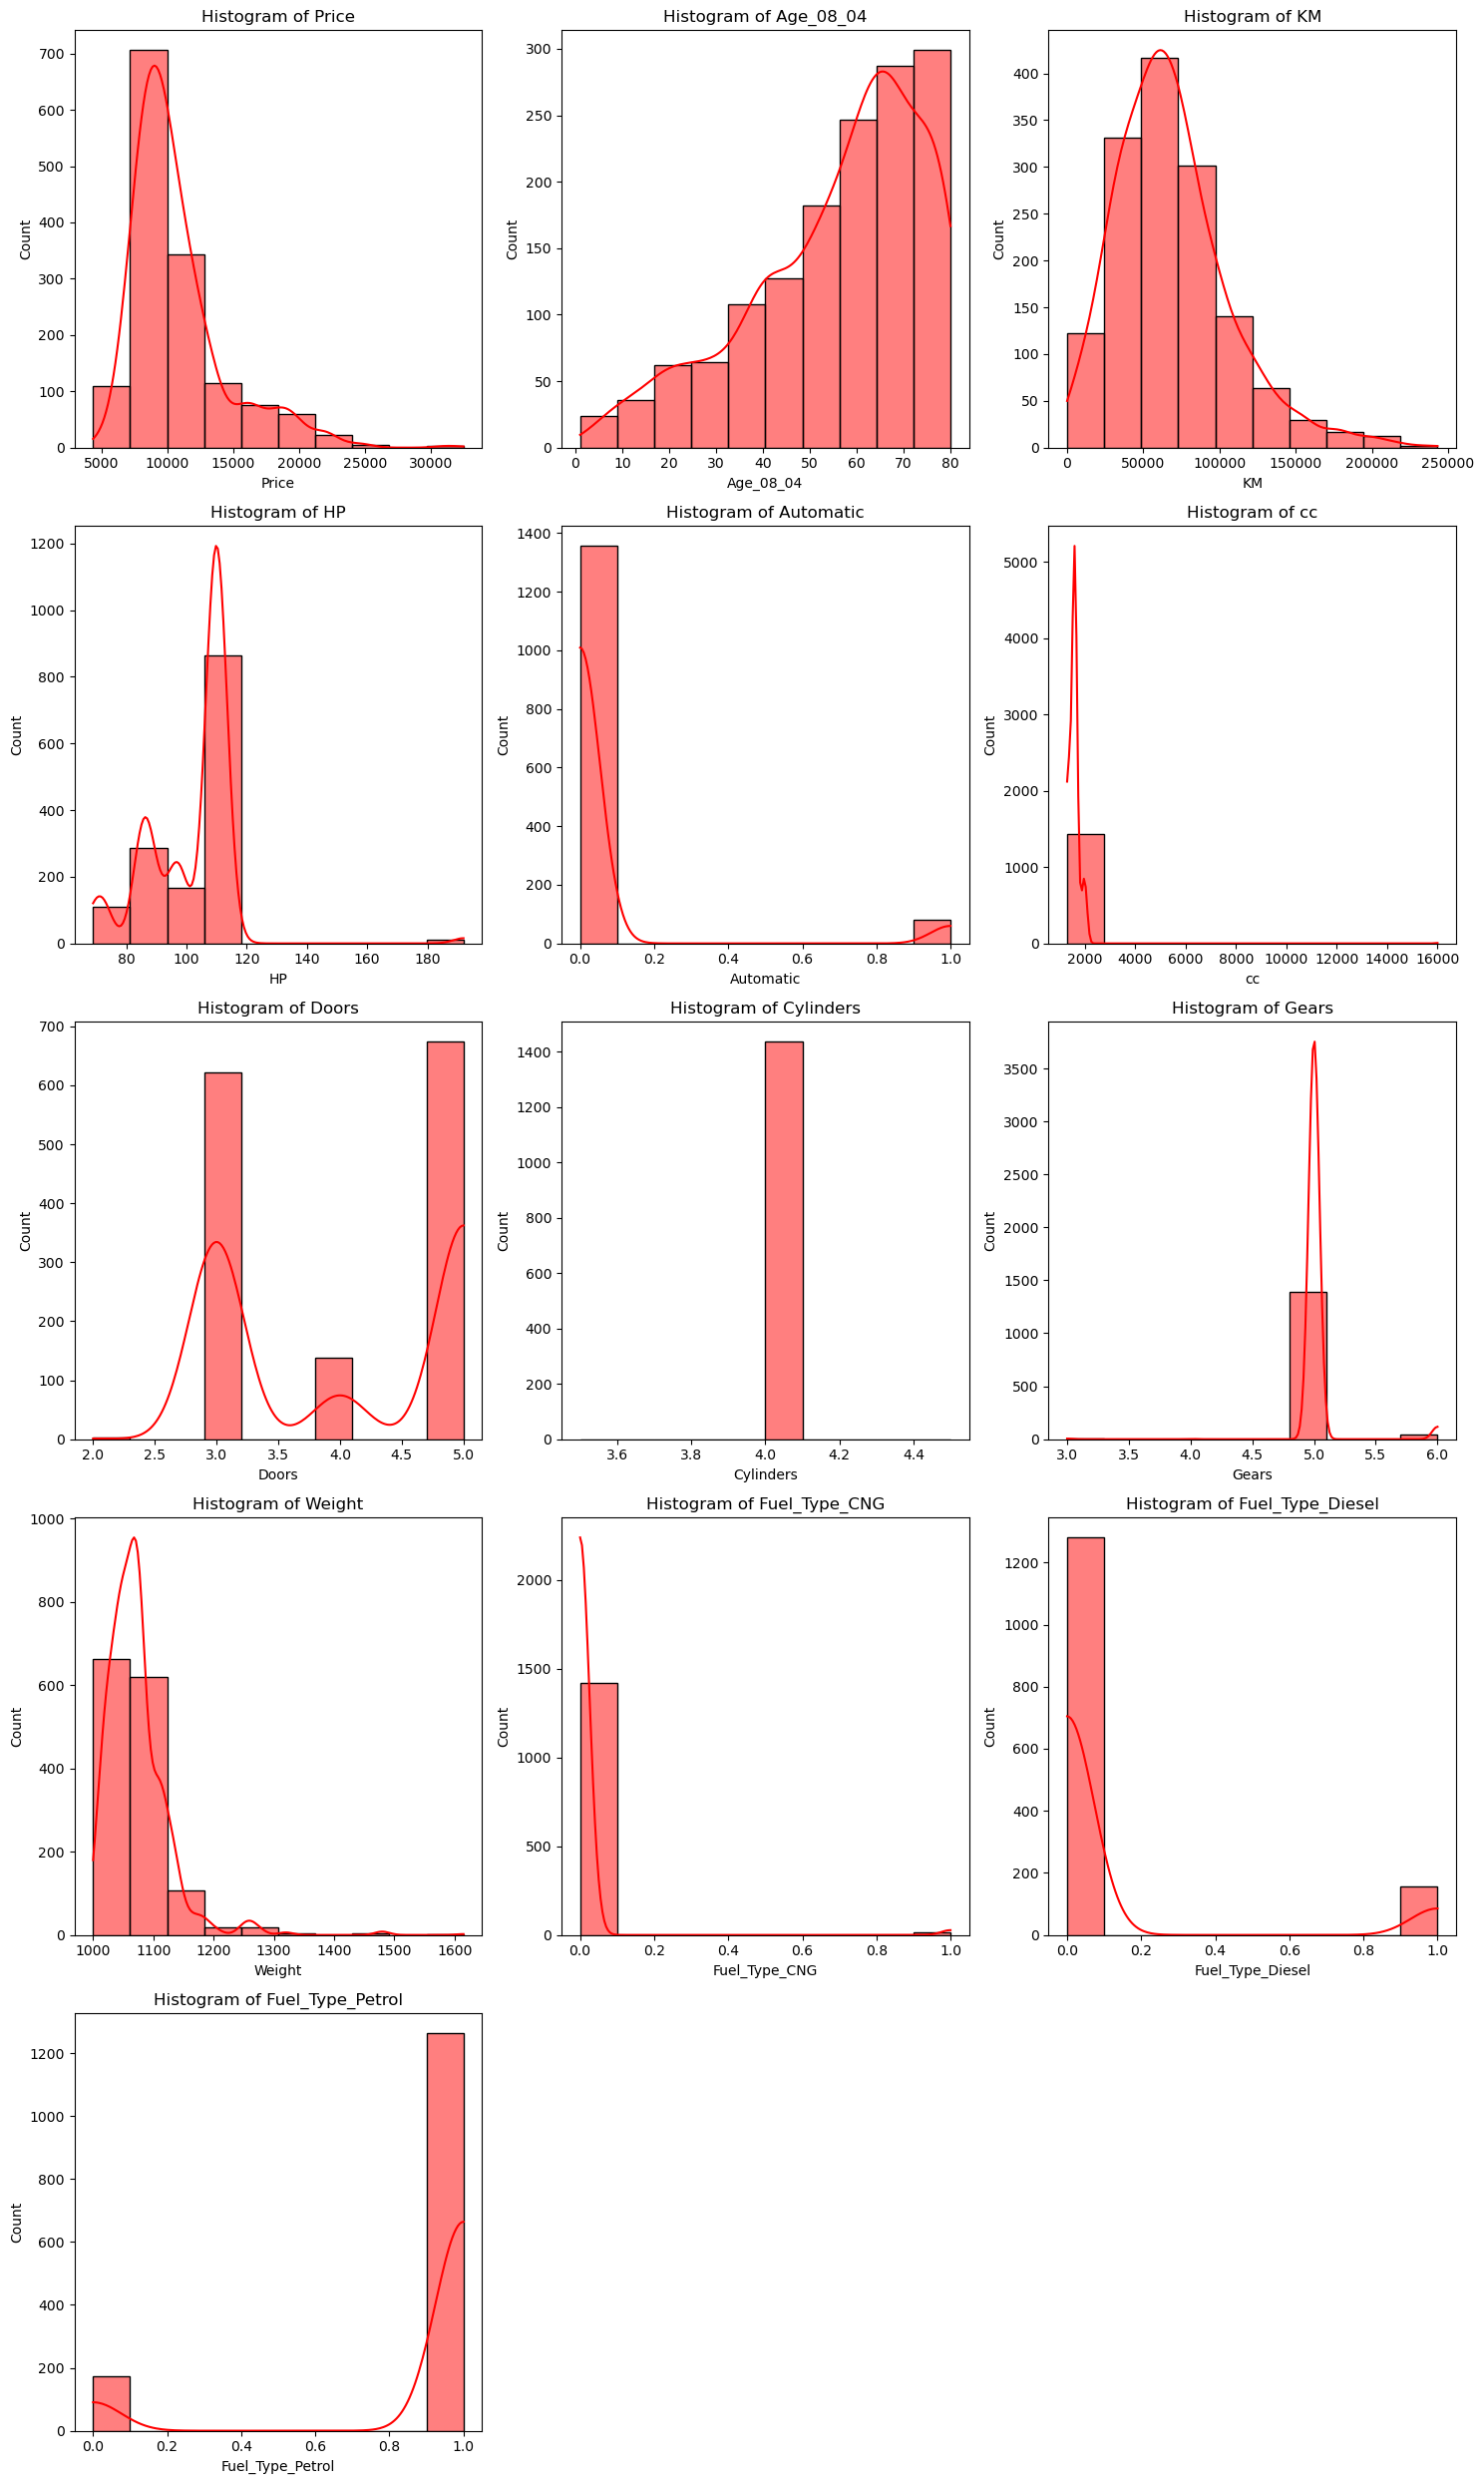

In [277]:
# Bar plots and histograms

import math

num_cols = len(df1.columns)
rows = math.ceil(num_cols/3)

plt.figure(figsize=(15, rows*5))
for i, col in enumerate(df1.columns,1):
    plt.subplot(rows,3,i)
    sns.histplot(df1[col], kde=True, bins=10, color='red')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [278]:
# Box plots

# Visualizing boxplots with matplotlib

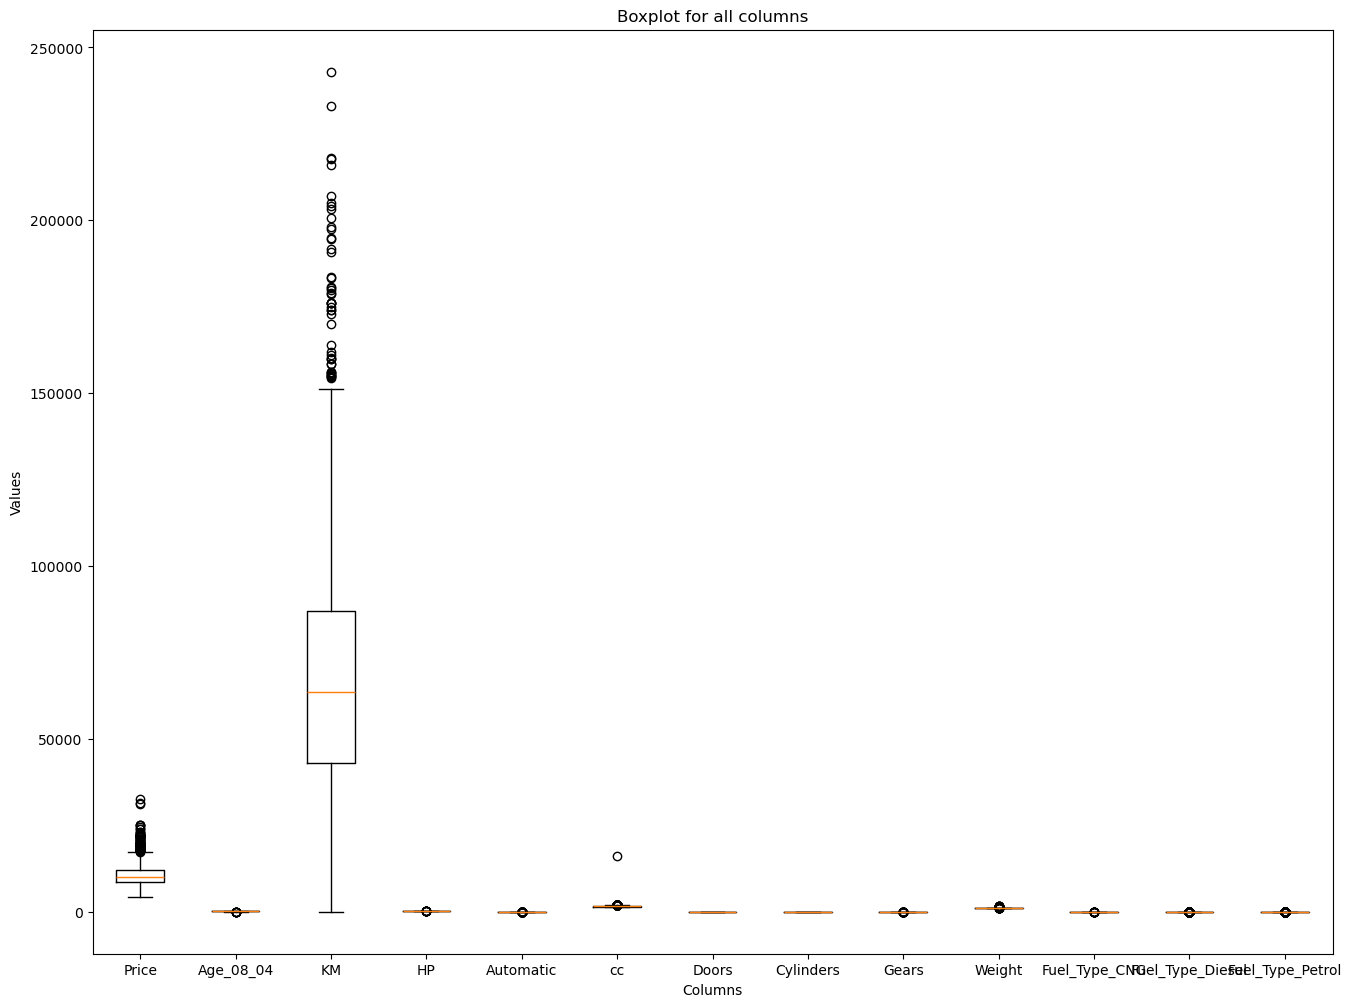

In [279]:
plt.figure(figsize=(16,12)) 
plt.boxplot([df1[col] for col in df1.columns], tick_labels=df1.columns)
plt.title("Boxplot for all columns")
plt.xlabel('Columns')
plt.ylabel('Values')
plt.show()

In [280]:
# Check for outliers and calculating the IQR

In [281]:
# Calculate IQR of column 'Age_08_04'
Q1 = df1['Age_08_04'].quantile(0.25)
Q3 = df1['Age_08_04'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['Age_08_04'] < (Q1 - 1.5 * IQR)) | (df1['Age_08_04'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound: ",Q1 - 1.5 * IQR)
print ("Upper bound: ", Q3 + 1.5 * IQR)

Outliers based on IQR:
      Price  Age_08_04    KM   HP  Automatic    cc  Doors  Cylinders  Gears  \
109  32500          4     1  116          0  2000      5          4      5   
110  31000          4  4000  116          0  2000      5          4      5   
111  31275          4  1500  116          0  2000      5          4      5   
182  21125          2   225   97          0  1400      5          4      5   
183  21500          2    15  110          0  1600      5          4      5   
184  17795          1     1   98          0  1400      4          4      5   
185  18245          1     1  110          0  1600      5          4      5   

     Weight  Fuel_Type_CNG  Fuel_Type_Diesel  Fuel_Type_Petrol  
109    1480              0                 1                 0  
110    1480              0                 1                 0  
111    1480              0                 1                 0  
182    1110              0                 0                 1  
183    1130              0

In [282]:
# Calculate IQR of column 'KM'
Q1 = df1['KM'].quantile(0.25)
Q3 = df1['KM'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['KM'] < (Q1 - 1.5 * IQR)) | (df1['KM'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound: ",Q1 - 1.5 * IQR)
print ("Upper bound: ", Q3 + 1.5 * IQR)

Outliers based on IQR:
       Price  Age_08_04      KM   HP  Automatic    cc  Doors  Cylinders  Gears  \
186    6950         43  243000   69          0  1900      3          4      5   
187    9500         38  180638   90          0  2000      4          4      5   
188   11950         40  179860   90          0  2000      5          4      5   
189    7750         43  178858  110          0  1600      3          4      5   
190   11950         40  161000   69          0  1900      3          4      5   
191    4350         44  158320   69          0  1800      5          4      5   
378    6500         53  216000   69          0  1900      3          4      5   
379    6400         51  198167   69          0  1900      4          4      5   
380    7000         53  176000   69          0  1900      3          4      5   
381    7750         54  174139   72          0  2000      4          4      5   
382    8900         45  174000   69          0  1900      5          4      5   
603 

In [283]:
# Calculate IQR of column 'HP'
Q1 = df1['HP'].quantile(0.25)
Q3 = df1['HP'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['HP'] < (Q1 - 1.5 * IQR)) | (df1['HP'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound: ",Q1 - 1.5 * IQR)
print ("Upper bound: ", Q3 + 1.5 * IQR)

Outliers based on IQR:
      Price  Age_08_04     KM   HP  Automatic    cc  Doors  Cylinders  Gears  \
8    21500         27  19700  192          0  1800      3          4      5   
10   20950         25  31461  192          0  1800      3          4      6   
11   19950         22  43610  192          0  1800      3          4      6   
12   19600         25  32189  192          0  1800      3          4      6   
13   21500         31  23000  192          0  1800      3          4      6   
14   22500         32  34131  192          0  1800      3          4      6   
15   22000         28  18739  192          0  1800      3          4      6   
16   22750         30  34000  192          0  1800      3          4      5   
49   21950         31  64982  192          0  1800      5          4      6   
53   21950         27  49866  192          0  1800      5          4      5   
141  23950         19  21684  192          0  1800      5          4      5   

     Weight  Fuel_Type_CNG 

In [284]:
# Calculate IQR of column 'cc'
Q1 = df1['cc'].quantile(0.25)
Q3 = df1['cc'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['cc'] < (Q1 - 1.5 * IQR)) | (df1['cc'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound: ",Q1 - 1.5 * IQR)
print ("Upper bound: ", Q3 + 1.5 * IQR)

Outliers based on IQR:
       Price  Age_08_04     KM  HP  Automatic    cc  Doors  Cylinders  Gears  \
0     13500         23  46986  90          0  2000      3          4      5   
1     13750         23  72937  90          0  2000      3          4      5   
2     13950         24  41711  90          0  2000      3          4      5   
3     14950         26  48000  90          0  2000      3          4      5   
4     13750         30  38500  90          0  2000      3          4      5   
...     ...        ...    ...  ..        ...   ...    ...        ...    ...   
1195   8750         74  89800  72          0  2000      3          4      5   
1202   6950         73  88186  72          0  2000      3          4      5   
1216   8500         70  85864  72          0  2000      5          4      5   
1320   9400         69  67092  72          0  2000      3          4      5   
1330   8950         71  65021  72          0  2000      3          4      5   

      Weight  Fuel_Type_CNG

In [285]:
# Calculate IQR of column 'Doors'
Q1 = df1['Doors'].quantile(0.25)
Q3 = df1['Doors'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['Doors'] < (Q1 - 1.5 * IQR)) | (df1['Doors'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound: ",Q1 - 1.5 * IQR)
print ("Upper bound: ", Q3 + 1.5 * IQR)

Outliers based on IQR:
 Empty DataFrame
Columns: [Price, Age_08_04, KM, HP, Automatic, cc, Doors, Cylinders, Gears, Weight, Fuel_Type_CNG, Fuel_Type_Diesel, Fuel_Type_Petrol]
Index: []
Number of outliers:  0
Lower bound:  0.0
Upper bound:  8.0


In [288]:
# Calculate IQR of column 'Price'
Q1 = df1['Price'].quantile(0.25)
Q3 = df1['Price'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['Price'] < (Q1 - 1.5 * IQR)) | (df1['Price'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound: ",Q1 - 1.5 * IQR)
print ("Upper bound: ", Q3 + 1.5 * IQR)

Outliers based on IQR:
      Price  Age_08_04     KM   HP  Automatic    cc  Doors  Cylinders  Gears  \
7    18600         30  75889   90          0  2000      3          4      5   
8    21500         27  19700  192          0  1800      3          4      5   
10   20950         25  31461  192          0  1800      3          4      6   
11   19950         22  43610  192          0  1800      3          4      6   
12   19600         25  32189  192          0  1800      3          4      6   
..     ...        ...    ...  ...        ...   ...    ...        ...    ...   
182  21125          2    225   97          0  1400      5          4      5   
183  21500          2     15  110          0  1600      5          4      5   
184  17795          1      1   98          0  1400      4          4      5   
185  18245          1      1  110          0  1600      5          4      5   
523  18950         49  49568  110          0  1600      3          4      5   

     Weight  Fuel_Type_CNG 

In [297]:
df1.shape

(1436, 13)

In [299]:
110/1436

0.0766016713091922

In [301]:
# Since there are 110 outliers in the target variable 'Price' and this accounts for 7% of the dataset values, these are removed.

In [303]:
# Define lower and upper bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

In [305]:
# Remove outliers from df1
df1_cleaned = df1[(df1['Price'] >= lower_bound) & (df1['Price'] <= upper_bound)]

# Print the new shape after removing outliers
print("Original dataset size:", df1.shape)
print("New dataset size after removing outliers:", df1_cleaned.shape)

Original dataset size: (1436, 13)
New dataset size after removing outliers: (1326, 13)


In [307]:
df1_cleaned

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,13500,23,46986,90,0,2000,3,4,5,1165,0,1,0
1,13750,23,72937,90,0,2000,3,4,5,1165,0,1,0
2,13950,24,41711,90,0,2000,3,4,5,1165,0,1,0
3,14950,26,48000,90,0,2000,3,4,5,1165,0,1,0
4,13750,30,38500,90,0,2000,3,4,5,1170,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,86,0,1300,3,4,5,1025,0,0,1
1432,10845,72,19000,86,0,1300,3,4,5,1015,0,0,1
1433,8500,71,17016,86,0,1300,3,4,5,1015,0,0,1
1434,7250,70,16916,86,0,1300,3,4,5,1015,0,0,1


In [309]:
# Calculate IQR of column 'Gears'
Q1 = df1['Gears'].quantile(0.25)
Q3 = df1['Gears'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['Gears'] < (Q1 - 1.5 * IQR)) | (df1['Gears'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound ",Q1 - 1.5 * IQR)
print ("Upper bound ", Q3 + 1.5 * IQR)

Outliers based on IQR:
       Price  Age_08_04      KM   HP  Automatic    cc  Doors  Cylinders  Gears  \
10    20950         25   31461  192          0  1800      3          4      6   
11    19950         22   43610  192          0  1800      3          4      6   
12    19600         25   32189  192          0  1800      3          4      6   
13    21500         31   23000  192          0  1800      3          4      6   
14    22500         32   34131  192          0  1800      3          4      6   
15    22000         28   18739  192          0  1800      3          4      6   
49    21950         31   64982  192          0  1800      5          4      6   
330   11000         41   33000  110          1  1600      5          4      6   
444   11750         48   75045  110          0  1600      3          4      6   
461   11950         49   69659   86          0  1300      3          4      6   
586    9950         55   29650   86          0  1300      3          4      6   
614 

In [311]:
# Calculate IQR of column 'Gears'
Q1 = df1['Cylinders'].quantile(0.25)
Q3 = df1['Cylinders'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['Cylinders'] < (Q1 - 1.5 * IQR)) | (df1['Cylinders'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound ",Q1 - 1.5 * IQR)
print ("Upper bound ", Q3 + 1.5 * IQR)

Outliers based on IQR:
 Empty DataFrame
Columns: [Price, Age_08_04, KM, HP, Automatic, cc, Doors, Cylinders, Gears, Weight, Fuel_Type_CNG, Fuel_Type_Diesel, Fuel_Type_Petrol]
Index: []
Number of outliers:  0
Lower bound  4.0
Upper bound  4.0


In [313]:
# Calculate IQR of column 'Gears'
Q1 = df1['Weight'].quantile(0.25)
Q3 = df1['Weight'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['Weight'] < (Q1 - 1.5 * IQR)) | (df1['Weight'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound ",Q1 - 1.5 * IQR)
print ("Upper bound ", Q3 + 1.5 * IQR)

Outliers based on IQR:
       Price  Age_08_04      KM  HP  Automatic    cc  Doors  Cylinders  Gears  \
0     13500         23   46986  90          0  2000      3          4      5   
1     13750         23   72937  90          0  2000      3          4      5   
2     13950         24   41711  90          0  2000      3          4      5   
3     14950         26   48000  90          0  2000      3          4      5   
4     13750         30   38500  90          0  2000      3          4      5   
...     ...        ...     ...  ..        ...   ...    ...        ...    ...   
601    7500         50       1  90          0  2000      3          4      5   
654    6950         65  114383  90          0  2000      3          4      5   
768   10950         59   78750  90          0  1975      5          4      5   
960    9390         66   50806  86          0  1300      3          4      5   
1044   5900         73  232940  72          0  2000      5          4      5   

      Weight  F

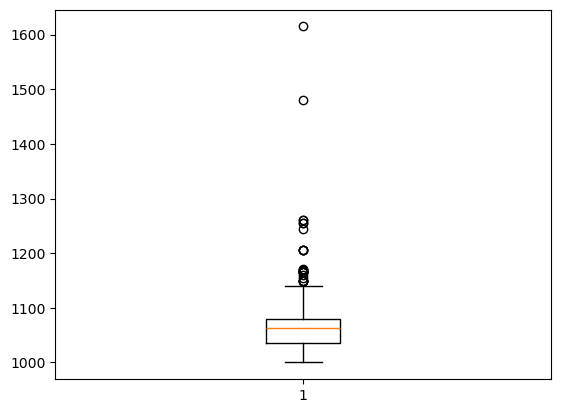

In [315]:
data_box_new=df1_cleaned.Weight
# Rechecking outlier removal of column 'Parch' in the new dataframe.
b=plt.boxplot(data_box_new)
plt.show()

In [317]:
# Calculate IQR of column 'Gears'
Q1 = df1['Automatic'].quantile(0.25)
Q3 = df1['Automatic'].quantile(0.75)
IQR = Q3 - Q1

# Identify outliers
outliers = df1[(df1['Automatic'] < (Q1 - 1.5 * IQR)) | (df1['Automatic'] > (Q3 + 1.5 * IQR))]
print("Outliers based on IQR:\n", outliers)
print ("Number of outliers: ",len(outliers))
print ("Lower bound ",Q1 - 1.5 * IQR)
print ("Upper bound ", Q3 + 1.5 * IQR)

Outliers based on IQR:
       Price  Age_08_04     KM   HP  Automatic     cc  Doors  Cylinders  Gears  \
21    16950         29  43905  110          1   1600      3          4      5   
52    20500         26  56000  110          1   1600      5          4      5   
54    15500         25  49163  110          1   1600      5          4      5   
58    18950         23  39704  110          1   1600      5          4      5   
80    18950         25  20019  110          1  16000      5          4      5   
...     ...        ...    ...  ...        ...    ...    ...        ...    ...   
1421   8500         78  36000   86          1   1300      3          4      5   
1423   7950         80  35821   86          1   1300      3          4      5   
1426   9950         78  30964  110          1   1600      3          4      4   
1427   8950         71  29000   86          1   1300      3          4      5   
1429   8950         78  24000   86          1   1300      5          4      5   

   

In [319]:
# Coulmns with outliers - 

# Price - outlier already removed and new dataframe copied as df1_cleaned.

# Other columns with outliers are - Age_08_04, KM, HP, cc, Gears, Cylinders, Weight, Automatic

In [321]:
df1_cleaned.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
count,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000,1326.0,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000
mean,9944.878582,59.159879,72297.084465,100.436652,0.053544,1557.601056,4.003017,4.0,5.023379,1064.779035,0.012821,0.099548,0.887632
std,2365.215061,15.278351,36154.781358,12.926620,0.225202,183.884406,0.952450,0.0,0.182799,41.034530,0.112542,0.299509,0.315938
min,4350.000000,13.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000,0.000000,0.000000,0.000000
25%,8250.000000,49.250000,47181.000000,86.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1035.000000,0.000000,0.000000,1.000000
50%,9500.000000,62.000000,66000.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1062.500000,0.000000,0.000000,1.000000
75%,10995.000000,71.000000,89789.250000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1079.750000,0.000000,0.000000,1.000000
max,17200.000000,80.000000,243000.000000,116.000000,1.000000,2000.000000,5.000000,4.0,6.000000,1615.000000,1.000000,1.000000,1.000000


In [323]:
columns_to_clean=['Age_08_04', 'KM', 'HP', 'cc', 'Cylinders', 'Weight']

# Automatic column has the values 0 and 1 and hence not removing it.
# Gears column has the values ranging from 3 to 6 and also mean and median are 5, hence not subjecting tooutlier treatment.

In [325]:
for col in df1_cleaned.columns:
    if col in columns_to_clean:
        Q1 = df1_cleaned[col].quantile(0.25)
        Q3 = df1_cleaned[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
    
        # Cap values individually
        df1_cleaned.loc[:,col] = np.clip(df1_cleaned[col], lower_bound, upper_bound)

print(df1_cleaned)

      Price  Age_08_04       KM   HP  Automatic    cc  Doors  Cylinders  \
0     13500       23.0  46986.0   90          0  1900      3          4   
1     13750       23.0  72937.0   90          0  1900      3          4   
2     13950       24.0  41711.0   90          0  1900      3          4   
3     14950       26.0  48000.0   90          0  1900      3          4   
4     13750       30.0  38500.0   90          0  1900      3          4   
...     ...        ...      ...  ...        ...   ...    ...        ...   
1431   7500       69.0  20544.0   86          0  1300      3          4   
1432  10845       72.0  19000.0   86          0  1300      3          4   
1433   8500       71.0  17016.0   86          0  1300      3          4   
1434   7250       70.0  16916.0   86          0  1300      3          4   
1435   6950       76.0      1.0  110          0  1600      5          4   

      Gears    Weight  Fuel_Type_CNG  Fuel_Type_Diesel  Fuel_Type_Petrol  
0         5  1146.875   

C:\Users\Smrithi\AppData\Local\Temp\ipykernel_44328\2633260058.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[23. 23. 24. ... 71. 70. 76.]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df1_cleaned.loc[:,col] = np.clip(df1_cleaned[col], lower_bound, upper_bound)
C:\Users\Smrithi\AppData\Local\Temp\ipykernel_44328\2633260058.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[4.6986e+04 7.2937e+04 4.1711e+04 ... 1.7016e+04 1.6916e+04 1.0000e+00]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df1_cleaned.loc[:,col] = np.clip(df1_cleaned[col], lower_bound, upper_bound)
C:\Users\Smrithi\AppData\Local\Temp\ipykernel_44328\2633260058.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '

In [327]:
# Outlier capping performed

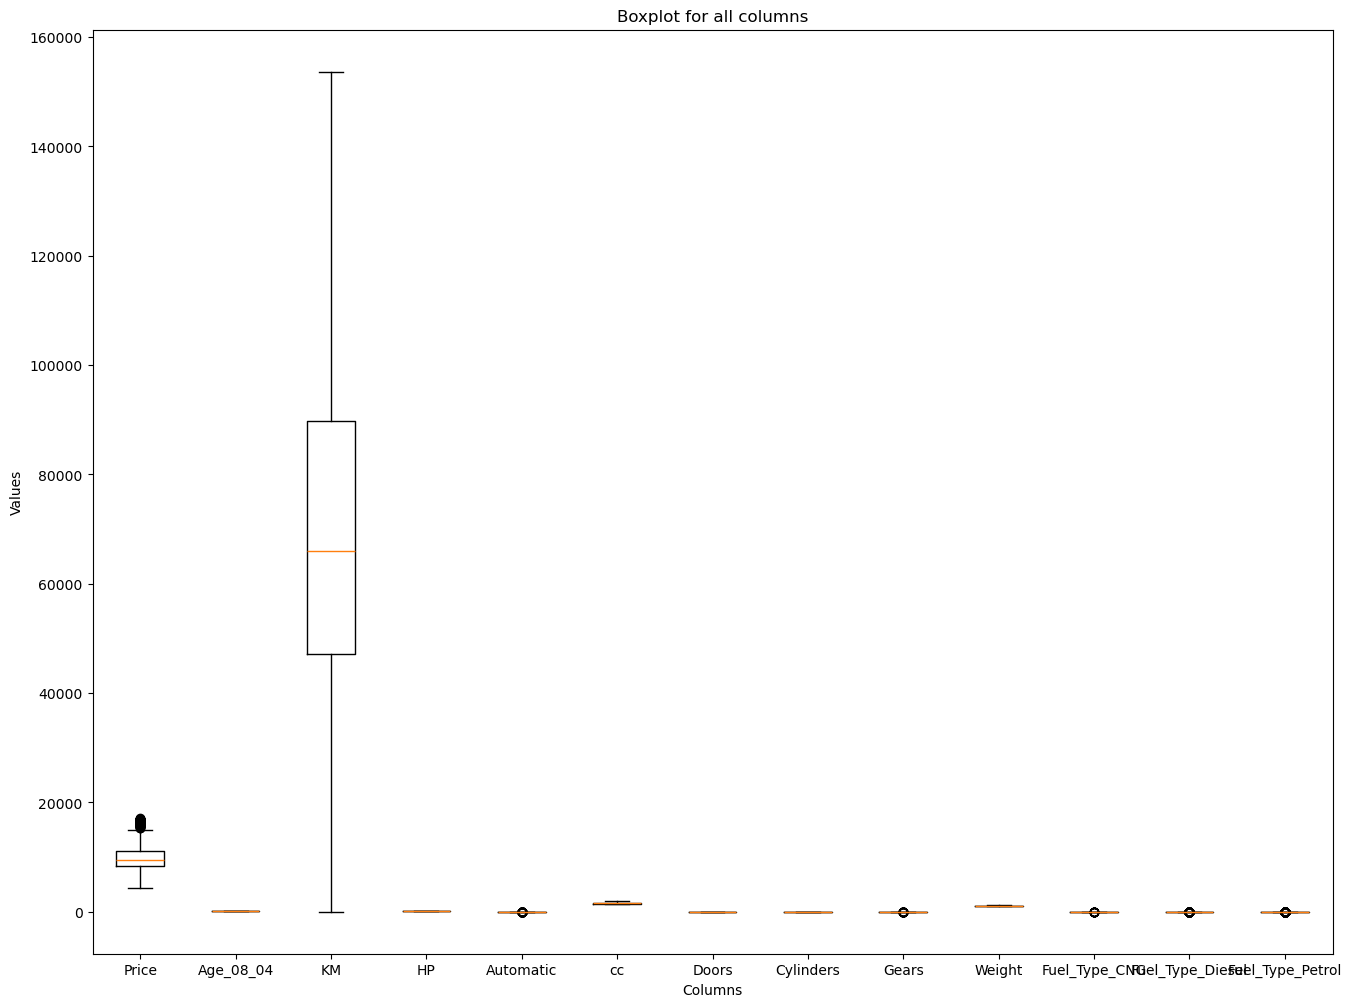

In [329]:
plt.figure(figsize=(16,12)) 
plt.boxplot([df1_cleaned[col] for col in df1_cleaned.columns], tick_labels=df1_cleaned.columns)
plt.title("Boxplot for all columns")
plt.xlabel('Columns')
plt.ylabel('Values')
plt.show()

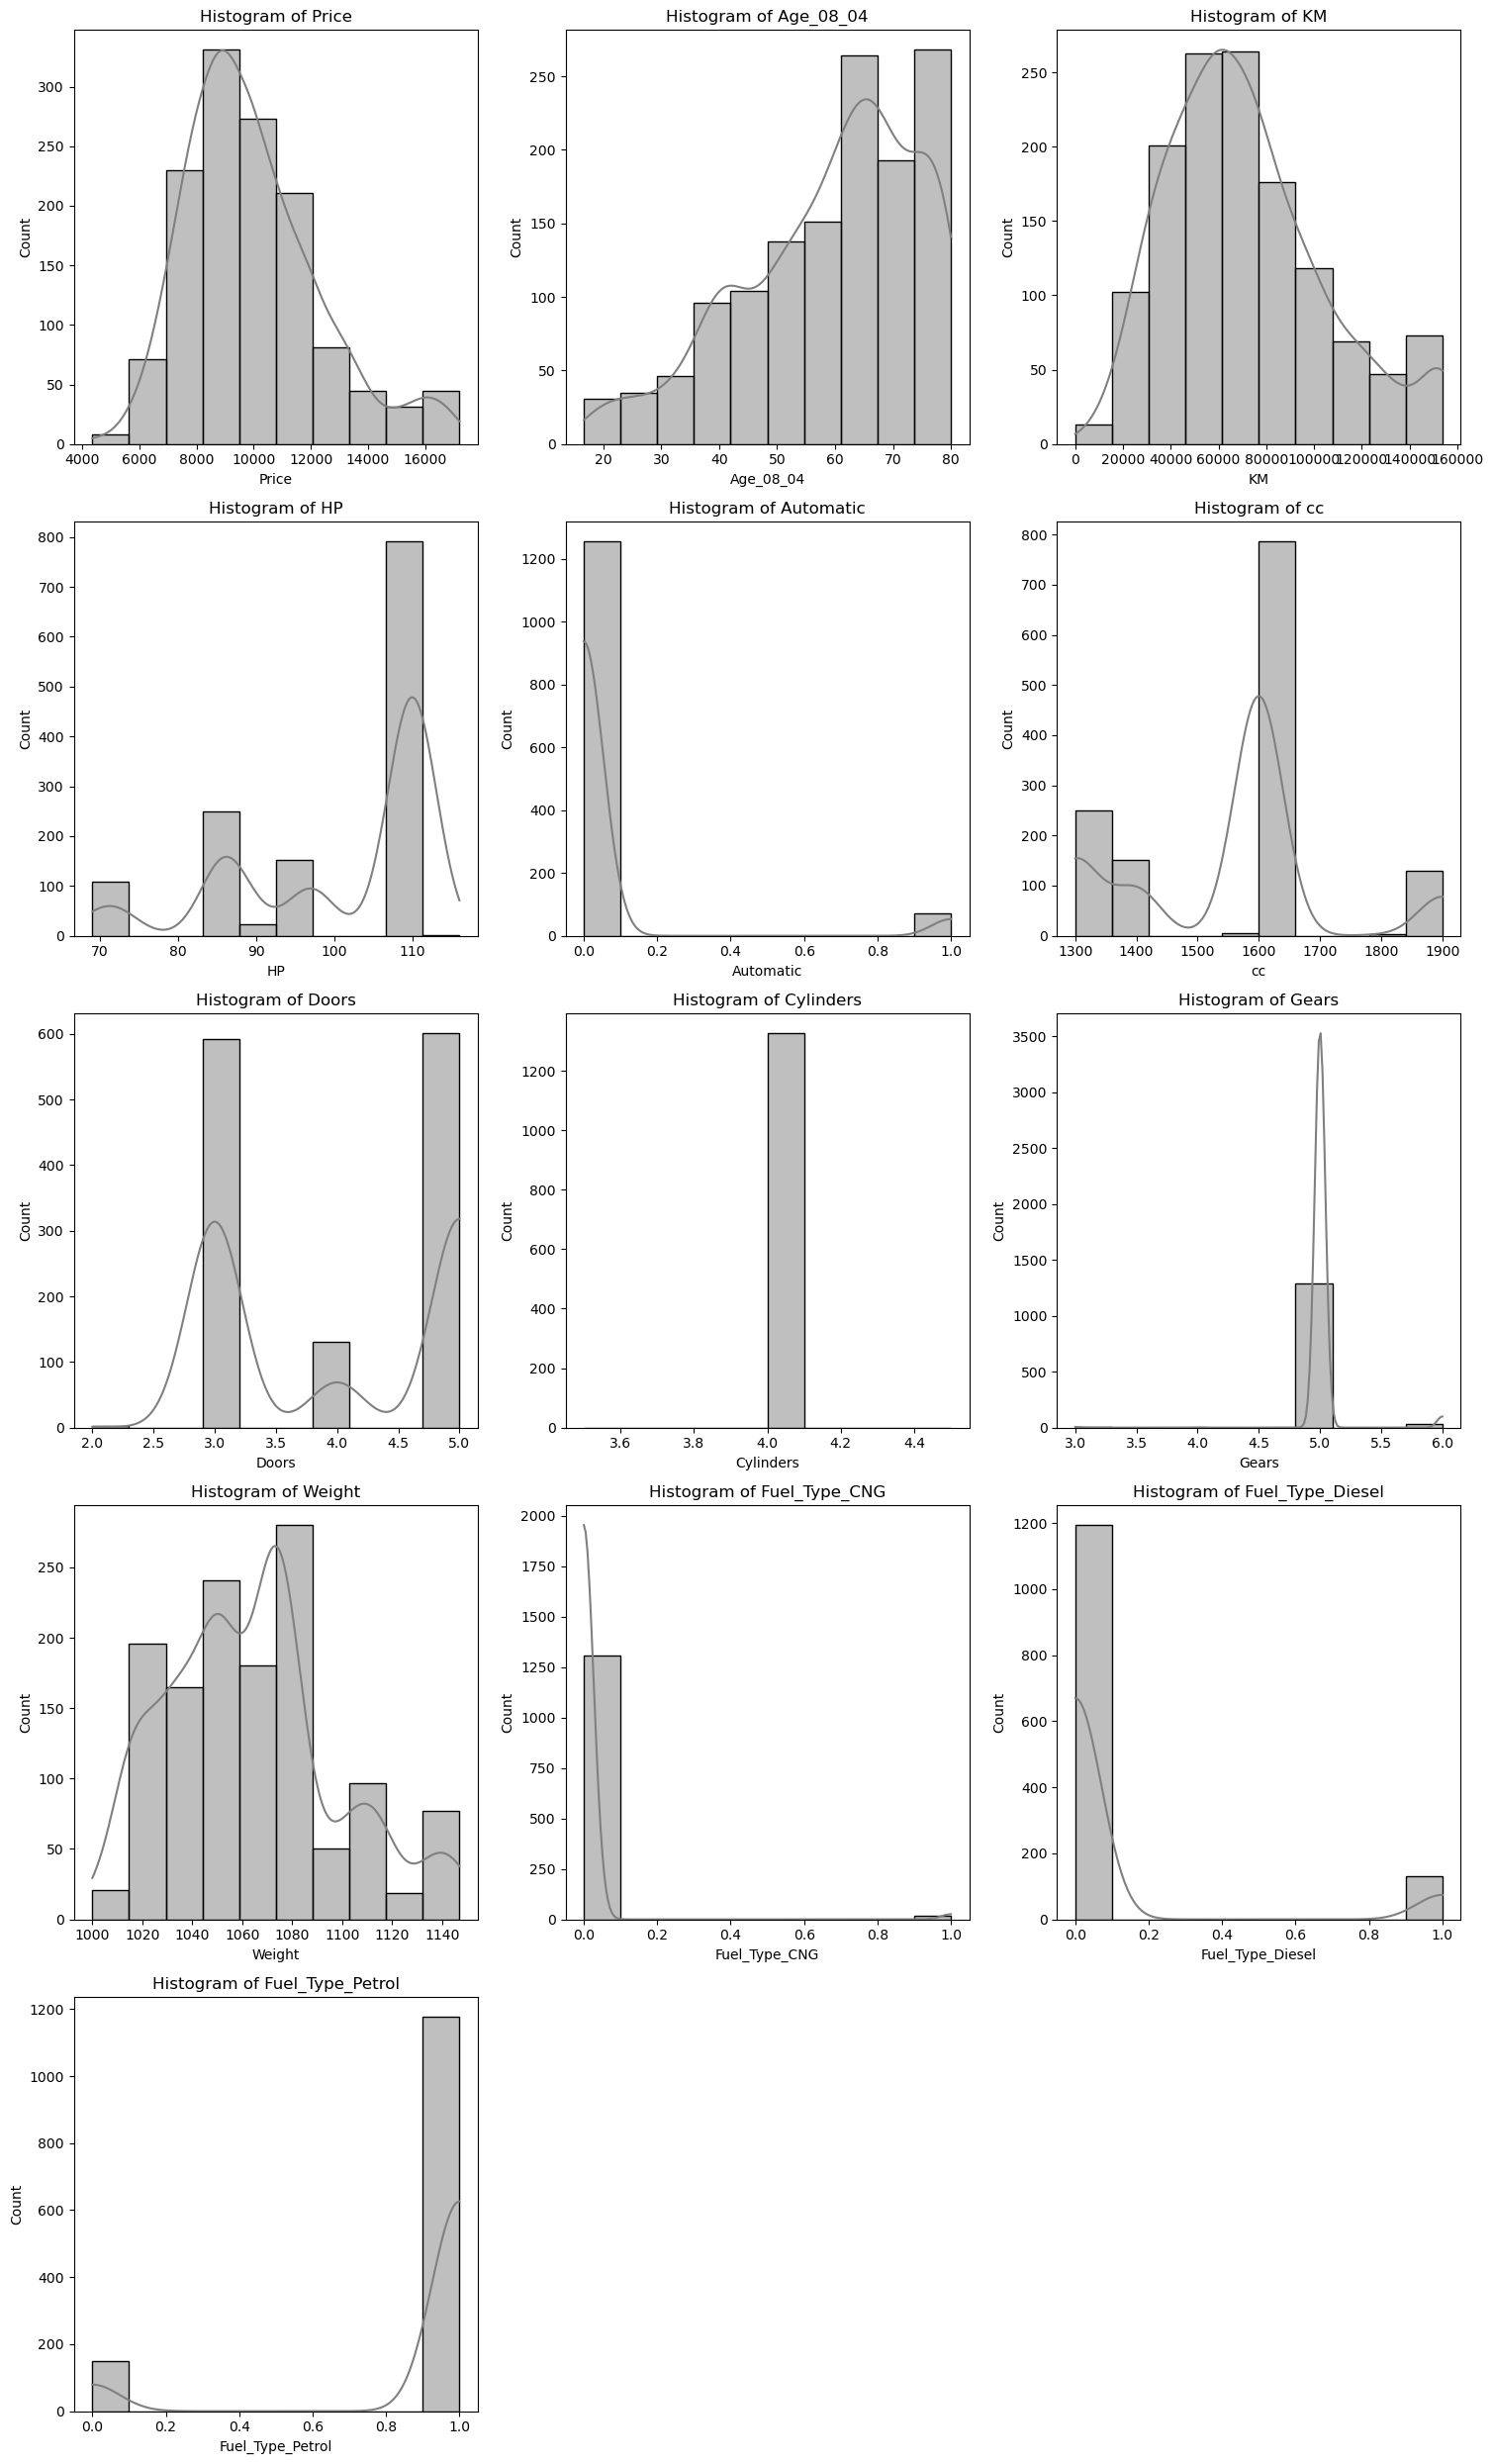

In [331]:
# Bar plots and histograms

import math

num_cols = len(df1_cleaned.columns)
rows = math.ceil(num_cols/3)

plt.figure(figsize=(15, rows*5))
for i, col in enumerate(df1_cleaned.columns,1):
    plt.subplot(rows,3,i)
    sns.histplot(df1_cleaned[col], kde=True, bins=10, color='grey')
    plt.title(f'Histogram of {col}')

plt.tight_layout()
plt.show()

In [333]:
df1_cleaned.isnull().sum()

Price               0
Age_08_04           0
KM                  0
HP                  0
Automatic           0
cc                  0
Doors               0
Cylinders           0
Gears               0
Weight              0
Fuel_Type_CNG       0
Fuel_Type_Diesel    0
Fuel_Type_Petrol    0
dtype: int64

In [335]:
df1_cleaned.shape

(1326, 13)

In [341]:
df1_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1326 entries, 0 to 1435
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Price             1326 non-null   int64  
 1   Age_08_04         1326 non-null   float64
 2   KM                1326 non-null   float64
 3   HP                1326 non-null   int64  
 4   Automatic         1326 non-null   int64  
 5   cc                1326 non-null   int64  
 6   Doors             1326 non-null   int64  
 7   Cylinders         1326 non-null   int64  
 8   Gears             1326 non-null   int64  
 9   Weight            1326 non-null   float64
 10  Fuel_Type_CNG     1326 non-null   int64  
 11  Fuel_Type_Diesel  1326 non-null   int64  
 12  Fuel_Type_Petrol  1326 non-null   int64  
dtypes: float64(3), int64(10)
memory usage: 145.0 KB


In [343]:
df1_cleaned.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
count,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000,1326.0,1326.000000,1326.000000,1326.000000,1326.000000,1326.000000
mean,9944.878582,59.171757,71315.692779,100.436652,0.053544,1550.153846,4.003017,4.0,5.023379,1063.379525,0.012821,0.099548,0.887632
std,2365.215061,15.243996,33197.055330,12.926620,0.225202,167.064124,0.952450,0.0,0.182799,33.827448,0.112542,0.299509,0.315938
min,4350.000000,16.625000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000,0.000000,0.000000,0.000000
25%,8250.000000,49.250000,47181.000000,86.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1035.000000,0.000000,0.000000,1.000000
50%,9500.000000,62.000000,66000.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1062.500000,0.000000,0.000000,1.000000
75%,10995.000000,71.000000,89789.250000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1079.750000,0.000000,0.000000,1.000000
max,17200.000000,80.000000,153701.625000,116.000000,1.000000,1900.000000,5.000000,4.0,6.000000,1146.875000,1.000000,1.000000,1.000000


In [345]:
# Correlation

corr_chart = df1_cleaned.corr()
corr_chart

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
Price,1.000000,-0.842899,-0.529772,0.196581,0.019743,0.027869,0.153564,NaN,0.022594,0.311948,-0.025242,-0.081856,0.086591
Age_08_04,-0.842899,1.000000,0.412520,-0.046390,0.063492,-0.055692,-0.095602,NaN,0.019142,-0.295665,-0.021081,-0.050363,0.055253
KM,-0.529772,0.412520,1.000000,-0.302662,-0.080064,0.346300,0.008418,NaN,0.037036,0.200587,0.143988,0.453196,-0.480920
HP,0.196581,-0.046390,-0.302662,1.000000,0.016592,0.060444,0.122798,NaN,0.079358,-0.076795,0.084342,-0.662123,0.597648
Automatic,0.019743,0.063492,-0.080064,0.016592,1.000000,-0.067941,-0.039458,NaN,-0.103764,0.072104,0.002672,-0.079085,0.074020
cc,0.027869,-0.055692,0.346300,0.060444,-0.067941,1.000000,0.137859,NaN,0.023360,0.737919,0.033934,0.692009,-0.668112
Doors,0.153564,-0.095602,0.008418,0.122798,-0.039458,0.137859,1.000000,NaN,-0.152123,0.396283,0.013721,0.012175,-0.016429
Cylinders,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gears,0.022594,0.019142,0.037036,0.079358,-0.103764,0.023360,-0.152123,NaN,1.000000,-0.027189,-0.051266,-0.042540,0.058589
Weight,0.311948,-0.295665,0.200587,-0.076795,0.072104,0.737919,0.396283,NaN,-0.027189,1.000000,0.116081,0.619965,-0.629076


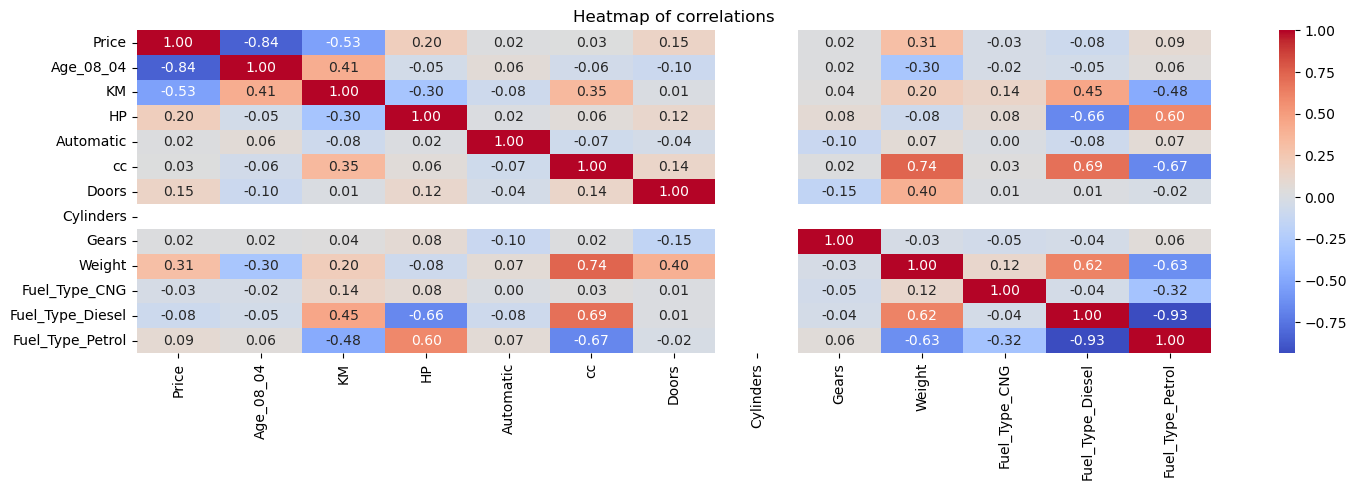

In [347]:
import seaborn as sns

plt.figure(figsize=(15,5))
sns.heatmap(corr_chart, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Heatmap of correlations')
plt.tight_layout()
plt.show()

In [349]:
df1_cleaned['Cylinders']

0       4
1       4
2       4
3       4
4       4
       ..
1431    4
1432    4
1433    4
1434    4
1435    4
Name: Cylinders, Length: 1326, dtype: int64

In [ ]:
# The columns 'Age_08-04' and 'Price' are strongly negatively correlated. However 'Price' is a target variable and therefore
# should not be considered for correlation check.
# The columns 'Weight' and 'cc' are moderately positive correlated.
# Fuel_Type_Petrol and Fuel_Type_Diesel are stringly negatively correlated.

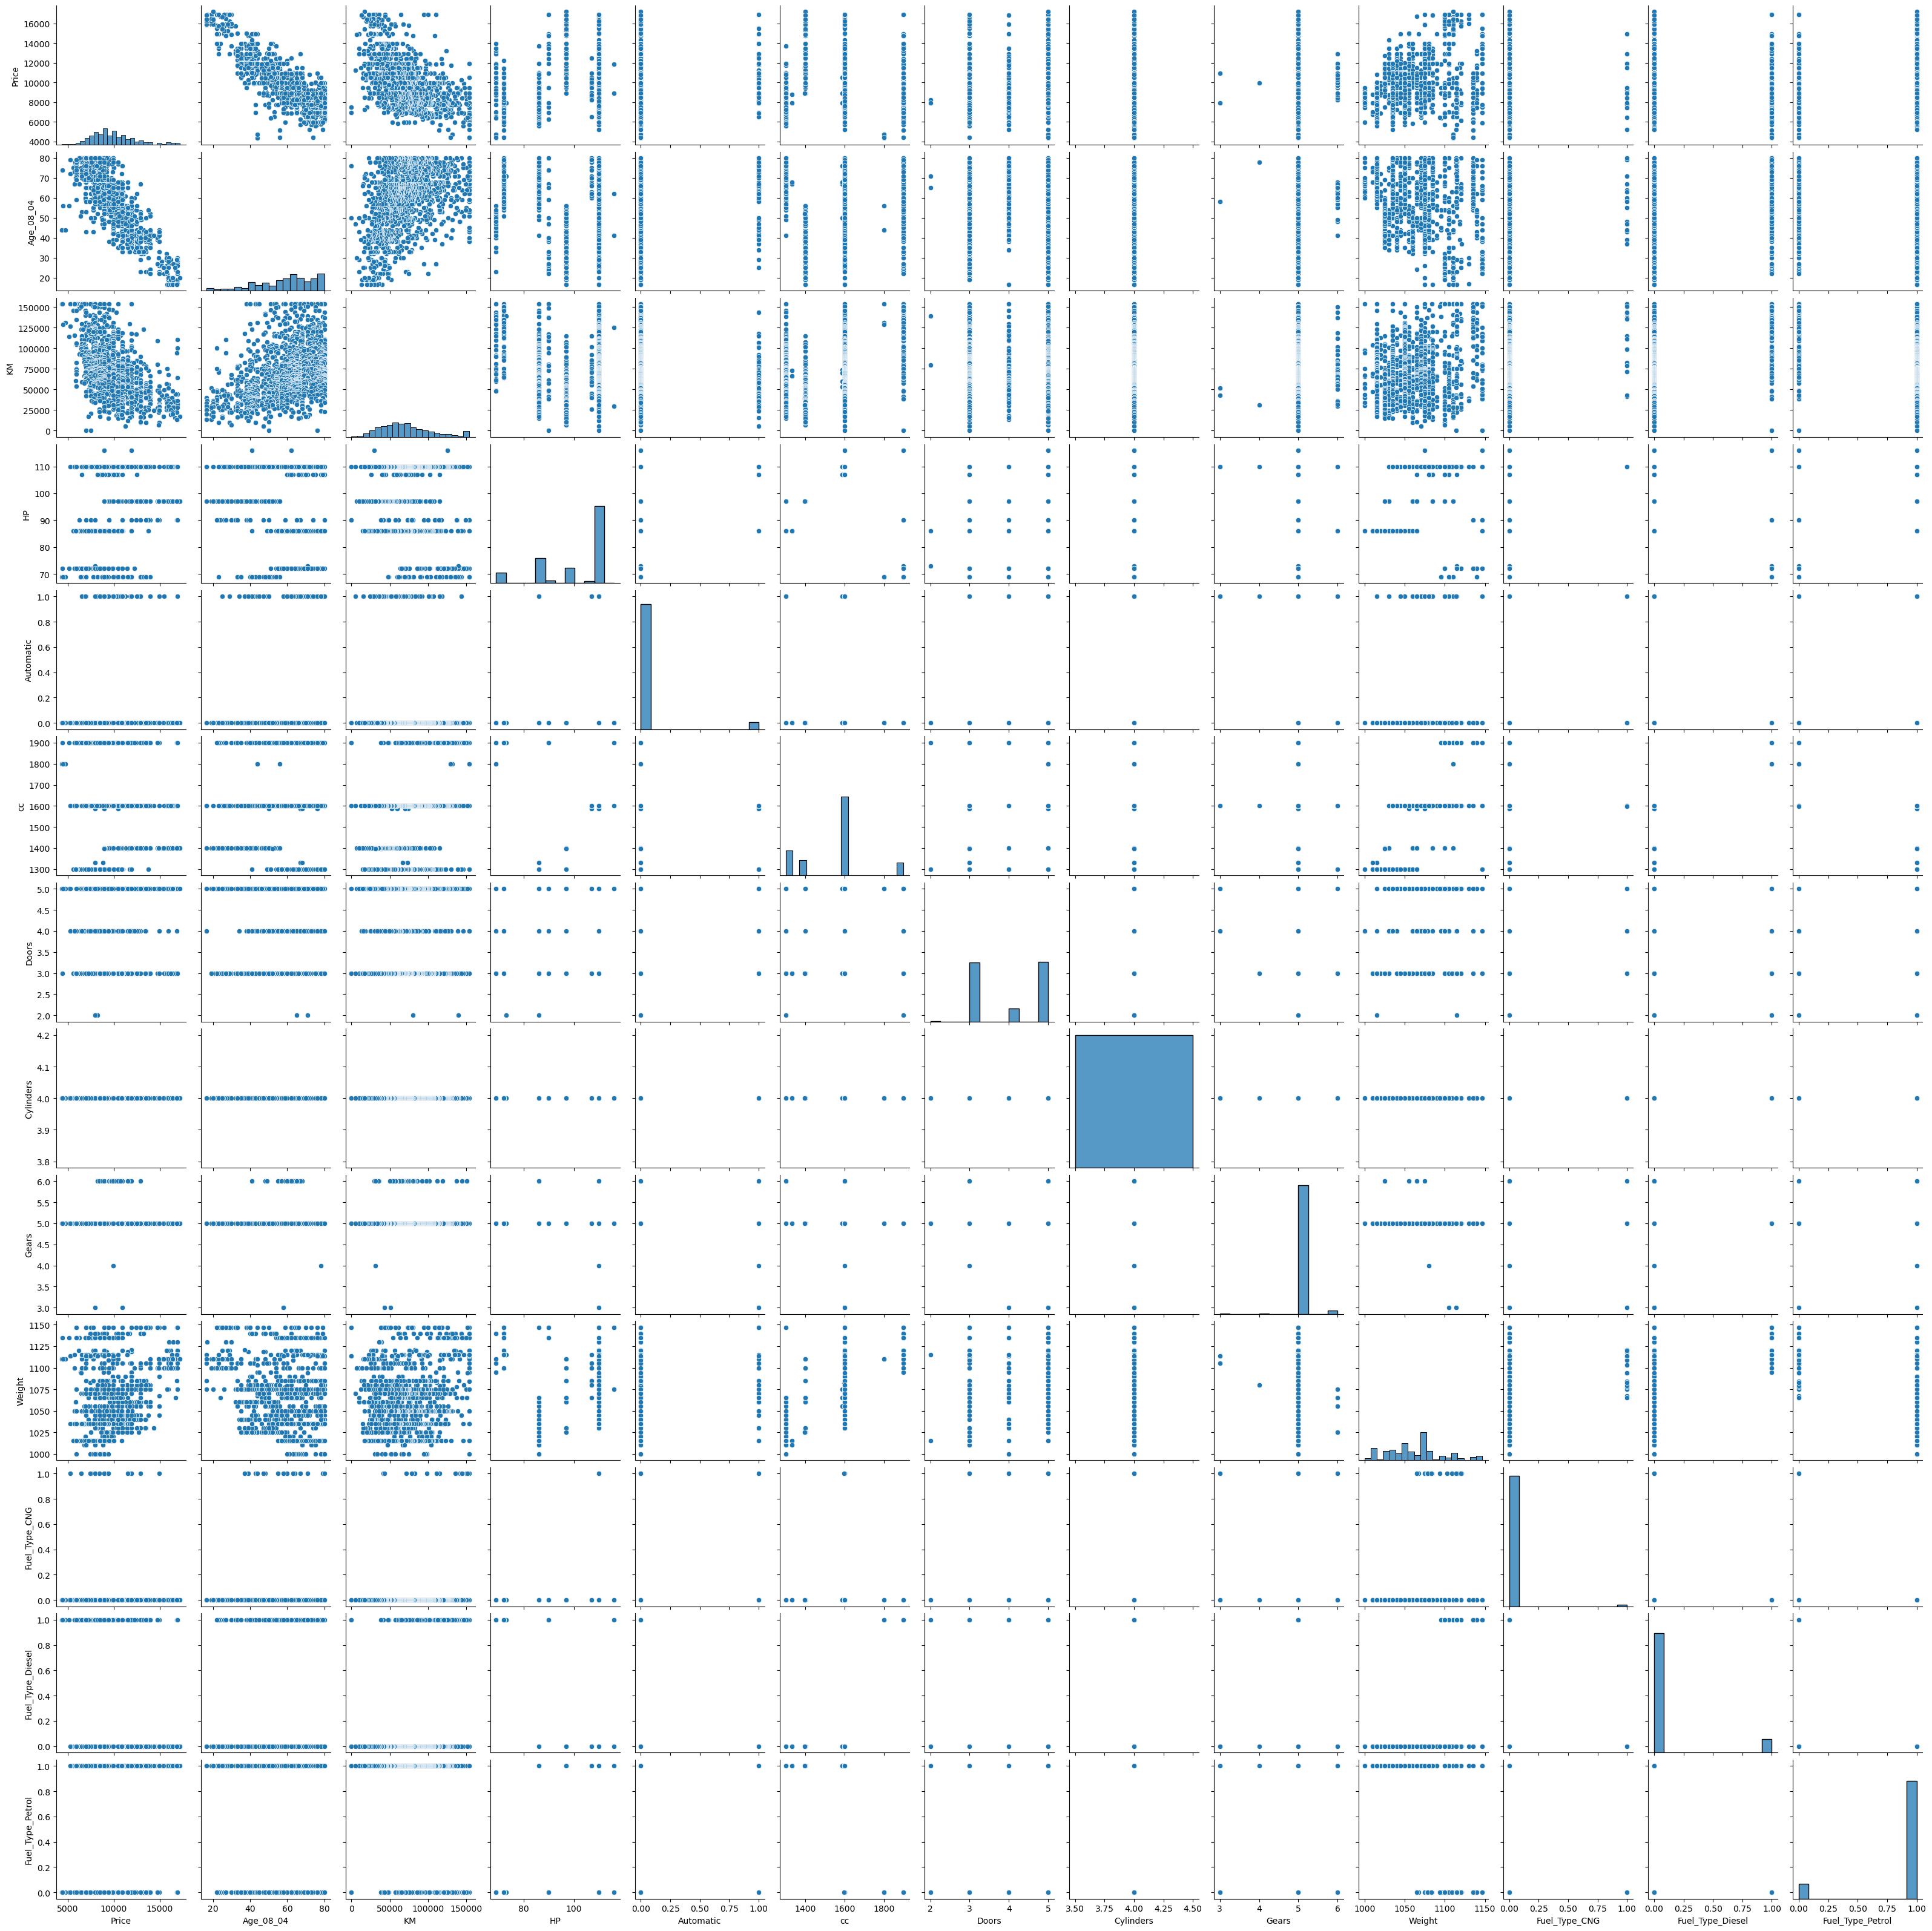

In [351]:
# Pair plot

sns.pairplot(df1_cleaned)
plt.show()

In [353]:
# Standardization

from numpy import set_printoptions
from sklearn.preprocessing import MinMaxScaler


In [355]:
df1_cleaned.values

array([[1.3500e+04, 2.3000e+01, 4.6986e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [1.3750e+04, 2.3000e+01, 7.2937e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       [1.3950e+04, 2.4000e+01, 4.1711e+04, ..., 0.0000e+00, 1.0000e+00,
        0.0000e+00],
       ...,
       [8.5000e+03, 7.1000e+01, 1.7016e+04, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [7.2500e+03, 7.0000e+01, 1.6916e+04, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00],
       [6.9500e+03, 7.6000e+01, 1.0000e+00, ..., 0.0000e+00, 0.0000e+00,
        1.0000e+00]])

In [357]:
d_value= df1_cleaned.values
scaler =MinMaxScaler(feature_range=(0,1))
rescaledX = scaler.fit_transform(d_value)

# Transform data
set_printoptions(precision=3)
print (rescaledX[0:5, :]) # First 5 rows and all columns of the normalized data will be printed

[[0.712 0.101 0.306 0.447 0.    1.    0.333 0.    0.667 1.    0.    1.
  0.   ]
 [0.732 0.101 0.475 0.447 0.    1.    0.333 0.    0.667 1.    0.    1.
  0.   ]
 [0.747 0.116 0.271 0.447 0.    1.    0.333 0.    0.667 1.    0.    1.
  0.   ]
 [0.825 0.148 0.312 0.447 0.    1.    0.333 0.    0.667 1.    0.    1.
  0.   ]
 [0.732 0.211 0.25  0.447 0.    1.    0.333 0.    0.667 1.    0.    1.
  0.   ]]


In [359]:
rescaledX

array([[0.712, 0.101, 0.306, ..., 0.   , 1.   , 0.   ],
       [0.732, 0.101, 0.475, ..., 0.   , 1.   , 0.   ],
       [0.747, 0.116, 0.271, ..., 0.   , 1.   , 0.   ],
       ...,
       [0.323, 0.858, 0.111, ..., 0.   , 0.   , 1.   ],
       [0.226, 0.842, 0.11 , ..., 0.   , 0.   , 1.   ],
       [0.202, 0.937, 0.   , ..., 0.   , 0.   , 1.   ]])

In [361]:
df_normalized = pd.DataFrame(rescaledX, columns=df1_cleaned.columns, index = df1_cleaned.index)

In [363]:
df_normalized

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,0.712062,0.100592,0.305692,0.446809,0.0,1.0,0.333333,0.0,0.666667,1.000000,0.0,1.0,0.0
1,0.731518,0.100592,0.474533,0.446809,0.0,1.0,0.333333,0.0,0.666667,1.000000,0.0,1.0,0.0
2,0.747082,0.116371,0.271372,0.446809,0.0,1.0,0.333333,0.0,0.666667,1.000000,0.0,1.0,0.0
3,0.824903,0.147929,0.312289,0.446809,0.0,1.0,0.333333,0.0,0.666667,1.000000,0.0,1.0,0.0
4,0.731518,0.211045,0.250480,0.446809,0.0,1.0,0.333333,0.0,0.666667,1.000000,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1431,0.245136,0.826430,0.133656,0.361702,0.0,0.0,0.333333,0.0,0.666667,0.170213,0.0,0.0,1.0
1432,0.505447,0.873767,0.123610,0.361702,0.0,0.0,0.333333,0.0,0.666667,0.102128,0.0,0.0,1.0
1433,0.322957,0.857988,0.110702,0.361702,0.0,0.0,0.333333,0.0,0.666667,0.102128,0.0,0.0,1.0
1434,0.225681,0.842209,0.110052,0.361702,0.0,0.0,0.333333,0.0,0.666667,0.102128,0.0,0.0,1.0


Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [365]:
from sklearn.model_selection import train_test_split

In [367]:
# Splitting data into X and Y

df1_cleaned.shape

(1326, 13)

In [385]:
X=df1_cleaned.iloc[:,1:13]
X

,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight,Fuel_Type_CNG,Fuel_Type_Diesel,Fuel_Type_Petrol
0,23.0,46986.0,90,0,1900,3,4,5,1146.875,0,1,0
1,23.0,72937.0,90,0,1900,3,4,5,1146.875,0,1,0
2,24.0,41711.0,90,0,1900,3,4,5,1146.875,0,1,0
3,26.0,48000.0,90,0,1900,3,4,5,1146.875,0,1,0
4,30.0,38500.0,90,0,1900,3,4,5,1146.875,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
1431,69.0,20544.0,86,0,1300,3,4,5,1025.000,0,0,1
1432,72.0,19000.0,86,0,1300,3,4,5,1015.000,0,0,1
1433,71.0,17016.0,86,0,1300,3,4,5,1015.000,0,0,1
1434,70.0,16916.0,86,0,1300,3,4,5,1015.000,0,0,1


In [387]:
Y=df1_cleaned.iloc[:,:1]
Y

,Price
0,13500
1,13750
2,13950
3,14950
4,13750
...,...
1431,7500
1432,10845
1433,8500
1434,7250


In [ ]:
# Splitting into train and test splits

In [389]:
x_train, x_test, y_train, y_test = train_test_split(X,Y,test_size=0.2, random_state=40)

In [381]:
# test_size=0.2 mean 80 by 20 split where 20% of data will be considered as test and remaining as training data.

In [391]:
x_train.shape

(1060, 12)

In [393]:
x_test.shape

(266, 12)

In [395]:
y_train.shape

(1060, 1)

In [397]:
y_test.shape

(266, 1)

Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build minimum of 3 different models.

In [ ]:
# # Build Multiple Linear Regression Models- Three models are as below:

# Baseline MLR Model (Using all features) - Model 1

# Feature-Selected Model (Using only significant predictors) - Model 2

# Polynomial Regression Model (Adding squared terms for non-linearity) - Model 3


In [401]:
# Model 1 - Baseline MLR model

from sklearn.linear_model import LinearRegression # Import linear regression

model1= LinearRegression()
model1.fit(x_train, y_train)

LinearRegression()

In [433]:
# Predictions
y_pred1=model1.predict(x_test)

In [435]:
from sklearn.metrics import r2_score, mean_squared_error

In [437]:
# Model evaluation
print ("Baseline Model - Rsquare score:", r2_score(y_test,y_pred1))
print ("Baseline Model - RMSE:", np.sqrt(mean_squared_error(y_test,y_pred1)))

Baseline Model - Rsquare score: 0.7647826680664871
Baseline Model - RMSE: 1097.3813849714052


In [449]:
# Model 2: Feature Selection-Based MLR

# Feature Selection Based MLR - Only highly correlated features are used for a more optimized model


# Features that are highly correlated -> absolute values more than 0.5 are as below:

import numpy as np

# Select highly correlated features manually (Keep features where |correlation| > 0.5 (even if negative).
# If two features are highly correlated with each other (r > 0.8), drop one to avoid multicollinearity. Refer extra reference notes in Word document)

# Step 1: Define the features we want to keep in our model
selected_features = ['Age_08_04', 'KM', 'HP', 'Fuel_Type_Diesel','cc','Weight'] # Since Petrol and Diesel are strongly negatively correlated, removing Petrol
# These features were chosen based on correlation analysis.

# Step 2: Ensure x_train is a DataFrame before selecting columns. Dataframe indexing works fine as below.
x_train_selected = x_train[selected_features]
x_test_selected = x_test[selected_features]

# Step 3: Initialize and train the model. The LinearRegression model is trained using only the selected features.
# Train the model 
model2 = LinearRegression()
model2.fit(x_train_selected, y_train)

# Step 4: Make predictions on the test set
y_pred2 = model2.predict(x_test_selected)

# Step 5: Evaluate the model's performance
print ("Feature-Selected Model - R square:", r2_score(y_test,y_pred2))
print ("Feature-Selected Model - RMSE:", np.sqrt(mean_squared_error(y_test,y_pred2)))

Feature-Selected Model - R square: 0.7626174894668865
Feature-Selected Model - RMSE: 1102.420520169515


In [451]:
# Model 3: Polynomial Regression

# This technique will introduce squared features to capture non-linearity

from sklearn.preprocessing import PolynomialFeatures

# Transform features using polynomial features
poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(x_train)
X_test_poly = poly.fit_transform(x_test)

# Train polynomial regression model
model3=LinearRegression()
model3.fit(X_train_poly, y_train)

# Predictions
y_pred3=model3.predict(X_test_poly)

# Model evaluation
print ("Polynomial regression model - R square:", r2_score(y_test, y_pred3))
print ("Polynomial regression model - RMSE: ", np.sqrt(mean_squared_error(y_test,y_pred3)))


Polynomial regression model - R square: -0.1626163645408949
Polynomial regression model - RMSE:  2439.726508618071


In [457]:
# Interpret Coefficients
# For the baseline model, we can check feature importance.
# Model1
coefficients = pd.DataFrame(model1.coef_.ravel(),index=X.columns, columns =['Coefficient'])
print (coefficients.sort_values(by='Coefficient',ascending=False))

                   Coefficient
Gears             5.585495e+02
Fuel_Type_Petrol  3.587959e+02
Fuel_Type_Diesel  2.729561e+02
Automatic         1.306844e+02
HP                2.429981e+01
Weight            1.990495e+01
Cylinders         5.684342e-14
KM               -1.394609e-02
cc               -2.226571e+00
Doors            -6.917962e+01
Age_08_04        -1.080559e+02
Fuel_Type_CNG    -6.317520e+02


In [461]:
# Model2

coefficients = pd.DataFrame(model2.coef_.ravel(),index=selected_features, columns =['Coefficient'])
print (coefficients.sort_values(by='Coefficient',ascending=False))

                  Coefficient
Fuel_Type_Diesel    92.092377
HP                  24.698458
Weight              17.566797
KM                  -0.014973
cc                  -2.111054
Age_08_04         -107.760279


In [469]:
# Model3

# Get transformed feature names
feature_names_poly = poly.get_feature_names_out(x_train.columns)

coefficients = pd.DataFrame(model3.coef_.ravel(),index=feature_names_poly, columns =['Coefficient'])
print (coefficients.sort_values(by='Coefficient',ascending=False))

                             Coefficient
Automatic Fuel_Type_Petrol  8.318282e+03
HP Cylinders                6.722181e+03
Cylinders Gears             3.283467e+03
Automatic Cylinders         3.028984e+03
HP Fuel_Type_Diesel         2.952965e+03
...                                  ...
Automatic Gears            -4.027951e+03
HP Fuel_Type_CNG           -4.150085e+03
HP Gears                   -6.272209e+03
Automatic Fuel_Type_CNG    -7.561036e+03
1                          -3.820616e+07

[91 rows x 1 columns]


In [485]:

from sklearn.metrics import mean_absolute_error
mae = mean_absolute_error(y_test, y_pred1)
print (f"MAE of Model 1 - {mae:.4f}")
mae = mean_absolute_error(y_test, y_pred2)
print (f"MAE of Model 2 - {mae:.4f}")
mae = mean_absolute_error(y_test, y_pred3)
print (f"MAE of Model 3 - {mae:.4f}")

MAE of Model 1 - 840.9572
MAE of Model 2 - 841.2056
MAE of Model 3 - 1742.2282


In [ ]:
# If MAE is low → Model makes smaller absolute errors on average.
Model 1 has the least MAE

# If RMSE is low → Predictions are close to actual values.
Model 1 has low RMSE

# If R² is high (close to 1) → Model explains most of the variance in the data.
Model 1 has highest RMSE

Model 1:
Baseline Model - Rsquare score: 0.7647826680664871
Baseline Model - RMSE: 1097.3813849714052
MAE of Model 1 - 840.9572

Model 2:
Feature-Selected Model - R square: 0.7626174894668865
Feature-Selected Model - RMSE: 1102.420520169515
MAE of Model 2 - 841.2056

Model 3:
Polynomial regression model - R square: -0.1626163645408949
Polynomial regression model - RMSE:  2439.726508618071
MAE of Model 3 - 1742.2282

In [491]:
from sklearn.linear_model import Lasso, Ridge
from sklearn.model_selection import GridSearchCV

# Define a range of alpha values for tuning
alpha_values = [0.001, 0.01, 0.1, 1, 10, 100]

# 📌 Model 4: Lasso Regression
lasso = Lasso()
lasso_cv = GridSearchCV(lasso, {'alpha': alpha_values}, cv=5)
lasso_cv.fit(x_train, y_train)

best_lasso = Lasso(alpha=lasso_cv.best_params_['alpha'])
best_lasso.fit(x_train, y_train)
y_pred_lasso = best_lasso.predict(x_test)

print("\nLasso Regression Results:")
print(f"Best Alpha: {lasso_cv.best_params_['alpha']}")
print(f"R² Score: {r2_score(y_test, y_pred_lasso)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_lasso))}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_lasso)}")

# Model 5: Ridge Regression
ridge = Ridge()
ridge_cv = GridSearchCV(ridge, {'alpha': alpha_values}, cv=5)
ridge_cv.fit(x_train, y_train)

best_ridge = Ridge(alpha=ridge_cv.best_params_['alpha'])
best_ridge.fit(x_train, y_train)
y_pred_ridge = best_ridge.predict(x_test)

print("\nRidge Regression Results:")
print(f"Best Alpha: {ridge_cv.best_params_['alpha']}")
print(f"R² Score: {r2_score(y_test, y_pred_ridge)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_pred_ridge))}")
print(f"MAE: {mean_absolute_error(y_test, y_pred_ridge)}")


C:\Users\Smrithi\anaconda3\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:697: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.357e+07, tolerance: 4.882e+05
  model = cd_fast.enet_coordinate_descent(



Lasso Regression Results:
Best Alpha: 1
R² Score: 0.7648318426615981
RMSE: 1097.2666695600574
MAE: 840.486668220817

Ridge Regression Results:
Best Alpha: 1
R² Score: 0.764998225379578
RMSE: 1096.8784398865218
MAE: 840.2014110499886


In [ ]:
###  Interpretation of Lasso & Ridge Regression Results Compared to Earlier Models

Let's compare Lasso & Ridge Regression with the earlier models (Baseline Model, Feature-Selected Model, and Polynomial Model).

---

### 1 Comparing R² Scores (Model Performance)
- Baseline Model:0.7648
- Feature-Selected Model:0.7626 (slightly worse)  
- Polynomial Model:-0.1626 (completely failed)  
- Lasso Regression:0.7648 (same as baseline)  
- Ridge Regression:0.7650 (slightly better than baseline)  

 Key Takeaway:
- Lasso performed identically to the baseline model and did not improve performance.  
- Ridge slightly improved performance by reducing overfitting.  
- Feature selection (Model 2) slightly reduced performance, meaning some removed features were useful.  
- Polynomial regression completely failed, likely due to overfitting and high variance.

---

### 2 Comparing RMSE (Prediction Error)
- Baseline Model RMSE:1097.38
- Feature-Selected Model RMSE:1102.42 (worse)  
- Polynomial Model RMSE:2439.72 (much worse)  
- Lasso Regression RMSE:1097.27 (almost identical to baseline)  
- Ridge Regression RMSE:1096.88 (lowest error, slightly better)  

Key Takeaway:
- Ridge had the lowest RMSE, meaning it makes the best predictions among all models.  
- Lasso had no impact compared to the baseline.  
- Polynomial regression had the worst RMSE, proving it overfitted the data.  

---

### 3 Comparing MAE (Absolute Prediction Error)
- Baseline Model MAE:840.96 
- Feature-Selected Model MAE:841.21
- Polynomial Model MAE:1742.23 (huge error)  
- Lasso Regression MAE:840.49 (slightly better than baseline)  
- Ridge Regression MAE:840.20 (best overall)  

Key Takeaway:
- Ridge had the lowest MAE, meaning it makes the most consistent predictions.  
- Lasso slightly improved MAE compared to the baseline.  
- Polynomial regression had the worst MAE, confirming it was a bad choice.  

---

### Final Conclusion: Which Model is Best?
A️  Ridge Regression is the best model.
   - Best R² Score (0.7650)
   - Lowest RMSE (1096.88)
   - Lowest MAE (840.20)
   - Ridge helped reduce overfitting and slightly improved accuracy.  

B Lasso Regression performed the same as the baseline.
   - Lasso is useful when we want to eliminate irrelevant features, but here it didn’t improve the model.

C️ Feature Selection Model (Model 2) slightly underperformed. 
   - Removing features caused a small drop in R² and increased error.  

D️ Polynomial Regression failed badly.
   - It overfitted the data, leading to worse predictions.  

---

###  What Do the Coefficients Mean?
- Lasso shrinks some coefficients close to zero, effectively removing less important features.  
- Ridge keeps all features but reduces the impact of large coefficients, preventing overfitting.  
- This is why Ridge performed slightly better while Lasso performed the same as the baseline (because it didn't remove significant features).  

---


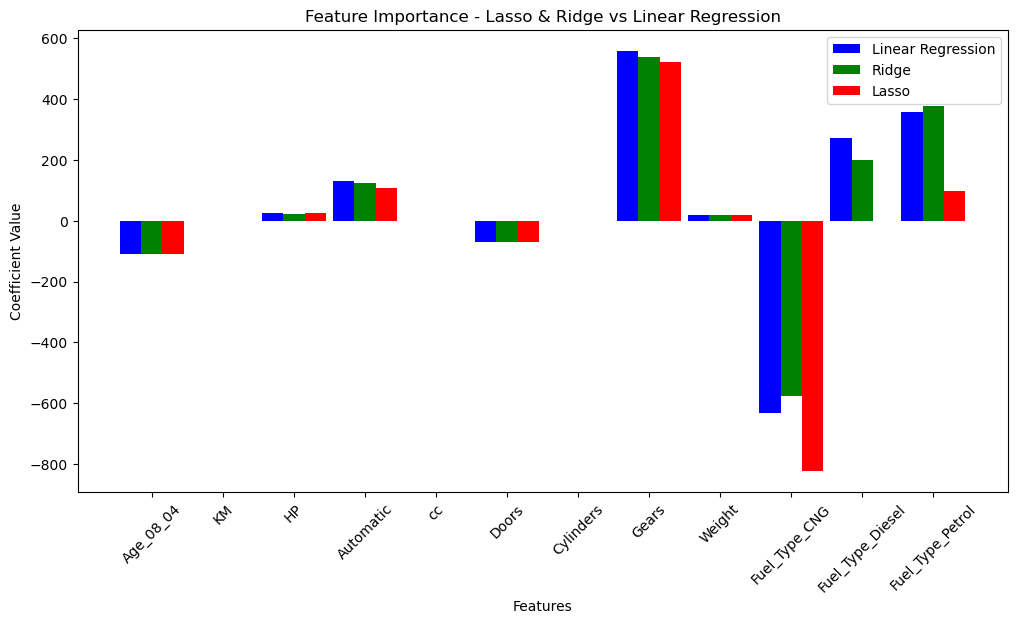

In [503]:
import numpy as np
import matplotlib.pyplot as plt

# Extract the best Lasso and Ridge models from GridSearchCV
best_lasso = lasso_cv.best_estimator_
best_ridge = ridge_cv.best_estimator_

# Extract coefficients
lasso_coefficients = best_lasso.coef_.ravel()  # Ensure it's a 1D array
ridge_coefficients = best_ridge.coef_.ravel()
baseline_coefficients = model1.coef_.ravel()

# Get feature names
feature_names = X.columns.tolist()  # Ensure it's a list

# Ensure coefficients match the number of features
if len(feature_names) != len(lasso_coefficients) or len(feature_names) != len(ridge_coefficients):
    print("Error: Mismatched coefficient dimensions!")
    print(f"Feature count: {len(feature_names)}, Lasso Coeffs: {len(lasso_coefficients)}, Ridge Coeffs: {len(ridge_coefficients)}")
else:
    # Define x-axis positions
    x = np.arange(len(feature_names))  # Corrected x-axis positions
    width = 0.3  # Bar width

    plt.figure(figsize=(12, 6))
    plt.bar(x - width, baseline_coefficients, width=width, label="Linear Regression", color='blue')
    plt.bar(x, ridge_coefficients, width=width, label="Ridge", color='green')
    plt.bar(x + width, lasso_coefficients, width=width, label="Lasso", color='red')

    # Formatting
    plt.xlabel("Features")
    plt.ylabel("Coefficient Value")
    plt.title("Feature Importance - Lasso & Ridge vs Linear Regression")
    plt.xticks(ticks=x, labels=feature_names, rotation=45)  # Rotate for better visibility
    plt.legend()
    plt.show()


In [ ]:
Considering the values of MAE, RMSE and R2 Ridge is the best model.

Ridge Regression reduces the magnitude of coefficients but retains all features making the model simpler. Hence ridge is the preferred model.